In [7]:
from fastapi import FastAPI, HTTPException, Header, Depends, Request
from pydantic import BaseModel
from dotenv import load_dotenv
import os

import requests
from typing import List, Dict, Optional

class GenerateRequest(BaseModel):
    model: str
    system_prompt: str = ''
    prompt: str
    format: Optional[dict] = None
    image: Optional[str] = None
    tools: Optional[List[Dict]] = None
    
    
class Agent0:
    
    def __init__(self, tools_desc, model):
        
        
        from dotenv import load_dotenv
        from sentence_transformers import CrossEncoder
        
        load_dotenv()
        
        
        
        self.model = model
        self.llmp_url = os.getenv("LLMP_URL")
        self.llmp_password = os.getenv("LLMP_PASSWORD")
        self.tools_desc = tools_desc
        self.cross_encoder = CrossEncoder("cross-encoder/ms-marco-MiniLM-L-6-v2")


        
    def llmp_call(self, prompt, system_prompt, model):
        """ 
        Call the LLMP API to generate a response
        All related to the call is processed here
        """
        
        headers = {
        "Content-Type": "application/json",
        "Authorization": self.llmp_password
    }
        
        # Construct request payload
        request_data = GenerateRequest(
        model=model,
        system_prompt=system_prompt,
        prompt=prompt,
        tools=None)
        
        payload = request_data.model_dump(exclude_none=True)

        try:
            response = requests.post(self.llmp_url, headers=headers, json=payload)
            response.raise_for_status()  # Raise an error for bad responses (4xx, 5xx)
            return response.json()
        except requests.exceptions.RequestException as e:
            print(f"Request failed: {e}")
            return None
        
    def agent_0_response(self, user_prompt):
        """ 
        Encompasses logic behind tool decision making
        Calls the llmp_call method to generate a response
        """
        
        system_prompt = "You are an assistant. Your only goal is to provide me the name of the tool I would need to get the answer to the prompt and nothing else."
        
        tools_description = "\n ".join([f"{key}: {value}" for key, value in self.tools_desc.items()])
        prompt = f"{user_prompt}\nwhich of the following tools would you use?\n {tools_description}"
        
        
        llmp_response = self.llmp_call(prompt, system_prompt, self.model)['message']['content']
        
        results = self.cross_encoder.predict([[llmp_response, tool] for tool in self.tools_desc.keys()])
        
        tool_scores = dict(zip(self.tools_desc.keys(), results))
        best_tool = max(tool_scores, key=tool_scores.get)
        
        
        return best_tool,results
    
    def agent_0_chat(self, user_prompt):
        """
        Logic behind tool activation.
        Sends to agent_0_response for tool decision.
        Activates tool.

        Args:
            user_prompt (str)
        """
        
        agent_0_response = self.agent_0_response(user_prompt)
        
        selected_tool = agent_0_response[0]
        print(selected_tool)
        
        if selected_tool == 'image_generator':
            
            from src.image_generator import ImageGeneratorAgent
            img_gen = ImageGeneratorAgent()
            img_gen.generate(user_prompt)
        

In [1]:
import sys
import os

project_root = os.path.abspath("..")

if project_root not in sys.path:
    sys.path.append(project_root)

from src.agent_0 import Agent0

In [2]:
# agent_0_tools_desc = {'conversational_agent':'a conversational assistant, designed to conduct simple conversations with users',
#               'image_generator':'a tool that generates images based on a given prompt',
#               'analyst_agent':'a tool that executes analytical or mathematical tasks',
#               'document_inspector':'a tool that inspects present documents and provides insights'}


agent_0_tools_desc = {'conversational_agent':'a conversational assistant, designed to conduct simple conversations with users',
              'image_generator':'a tool that generates images based on a given prompt. Should be triggered by explicit calls like "generate me an image of"'
              }

agent_0 = Agent0(agent_0_tools_desc, "llama3.2:latest")

h:\projects\ai_based\Agent-Factory\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
h:\projects\ai_based\Agent-Factory\.venv\Lib\site-packages\transformers\utils\hub.py:106: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(


In [3]:
user_prompt = 'generate me an artistic image of a blond 9 year old girl riding skates'
agent_0_output = agent_0.agent_0_response(user_prompt)

In [4]:
agent_0_output[1]

'generate me an artistic image of a blond 9 year old girl riding skates'

In [7]:
user_prompt = 'generate me an artistic image of a blond 9 year old girl riding roller skates'
agent_0_output = agent_0.agent_0_chat(user_prompt)

Passing to 
image_generator !
black-forest-labs/FLUX.1-schnell


Loading pipeline components...: 100%|██████████| 7/7 [00:06<00:00,  1.16it/s]


Matching configuration found in ../img_outputs\images_6.


100%|██████████| 2/2 [01:41<00:00, 50.74s/it]


Saved image with seed 651044 to ../img_outputs\images_6\8_2\image_seed_651044.png


In [8]:
for i in range(10):
    user_prompt = 'generate me an artistic image of a blond 9 year old girl riding roller skates'
    agent_0_output = agent_0.agent_0_chat(user_prompt)

Passing to 
image_generator !
black-forest-labs/FLUX.1-schnell


Loading pipeline components...: 100%|██████████| 7/7 [00:05<00:00,  1.19it/s]


Matching configuration found in ../img_outputs\images_6.


100%|██████████| 2/2 [01:41<00:00, 50.59s/it]


Saved image with seed 72418 to ../img_outputs\images_6\8_2\image_seed_72418.png
Passing to 
image_generator !
black-forest-labs/FLUX.1-schnell


...

Saved image with seed 560739 to ../img_outputs\images_6\8_2\image_seed_560739.png
Passing to 
image_generator !
black-forest-labs/FLUX.1-schnell


Loading pipeline components...: 100%|██████████| 7/7 [00:05<00:00,  1.17it/s]


Matching configuration found in ../img_outputs\images_6.


100%|██████████| 2/2 [01:40<00:00, 50.04s/it]


Saved image with seed 968259 to ../img_outputs\images_6\8_2\image_seed_968259.png


In [23]:
import pandas as pd

data = []
for prompt in user_prompts:
    for _ in range(20):
        data.append((prompt, "", ""))  # Empty values for selected_tool and value

# Create DataFrame
df = pd.DataFrame(data, columns=["user_prompt", "selected_tool", "values"])


df = pd.DataFrame([(prompt, "") for prompt in user_prompts for _ in range(20)], columns=["user_prompt", "selected_tool"])

# Apply the function to each row using a lambda function
df[["selected_tool", "values"]] = df["user_prompt"].apply(lambda x: pd.Series(agent_0.agent_0_response(x)))

# Expand array values into separate columns
df_values = pd.DataFrame(df["values"].tolist(), columns=[f"value_{i}" for i in range(len(df["values"].iloc[0]))])

# Merge with the original DataFrame
df = pd.concat([df.drop(columns=["values"]), df_values], axis=1)

In [2]:
from src.image_generator import ImageGeneratorAgent

h:\projects\ai_based\Agent-Factory\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
h:\projects\ai_based\Agent-Factory\.venv\Lib\site-packages\transformers\utils\hub.py:106: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(


In [5]:
sys.path

['h:\\projects\\ai_based\\Agent-Factory\\experiments',
 'H:\\AppData\\Local\\Programs\\Python\\Python312\\python312.zip',
 'H:\\AppData\\Local\\Programs\\Python\\Python312\\DLLs',
 'H:\\AppData\\Local\\Programs\\Python\\Python312\\Lib',
 'H:\\AppData\\Local\\Programs\\Python\\Python312',
 'h:\\projects\\ai_based\\Agent-Factory\\.venv',
 '',
 'h:\\projects\\ai_based\\Agent-Factory\\.venv\\Lib\\site-packages',
 'h:\\projects\\ai_based\\Agent-Factory\\.venv\\Lib\\site-packages\\win32',
 'h:\\projects\\ai_based\\Agent-Factory\\.venv\\Lib\\site-packages\\win32\\lib',
 'h:\\projects\\ai_based\\Agent-Factory\\.venv\\Lib\\site-packages\\Pythonwin',
 'h:\\projects\\ai_based\\Agent-Factory']

In [2]:
import sys
import os

project_root = os.path.abspath("..")

if project_root not in sys.path:
    sys.path.append(project_root)


from src.image_generator import ImageGeneratorAgent





prompt = "generate me an image of a cat"

img_gen = ImageGeneratorAgent()
img_gen.generate(prompt)

h:\projects\ai_based\Agent-Factory\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
h:\projects\ai_based\Agent-Factory\.venv\Lib\site-packages\transformers\utils\hub.py:106: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(


In [1]:
import torch

print("PyTorch Version:", torch.__version__)
print("CUDA Available:", torch.cuda.is_available())
print("CUDA Version:", torch.version.cuda)
print("Torch Backend CUDA Compiled:", torch.backends.cuda.is_built())
print("Torch GPU Count:", torch.cuda.device_count())
print("Torch Device Name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU Found")


PyTorch Version: 2.6.0+cu124
CUDA Available: True
CUDA Version: 12.4
Torch Backend CUDA Compiled: True
Torch GPU Count: 1
Torch Device Name: NVIDIA GeForce RTX 3050


In [1]:
import subprocess
import sys
import torch

def install_pytorch_cuda():
    try:
        # Check if CUDA-enabled PyTorch is already installed
        if torch.cuda.is_available():
            print("✅ PyTorch with CUDA is already installed.")
            return
        else:
            print("⚠️ PyTorch does not have CUDA support. Installing CUDA-enabled PyTorch...")

    except ImportError:
        print("❌ PyTorch is not installed. Installing now...")

    # Install PyTorch with CUDA via Poetry
    try:
        subprocess.run([
            "poetry", "run", "pip", "install", 
            "torch", "torchvision", "torchaudio", 
            "--index-url", "https://download.pytorch.org/whl/cu124"
        ], check=True)
        
        print("✅ PyTorch with CUDA installed successfully.")

    except subprocess.CalledProcessError as e:
        print(f"❌ Installation failed: {e}")
        sys.exit(1)

# Run installation check
install_pytorch_cuda()

⚠️ PyTorch does not have CUDA support. Installing CUDA-enabled PyTorch...
✅ PyTorch with CUDA installed successfully.


In [10]:
correct_tool_mapping = {
    'given my documents, what is quantum mechanics?': "document_inspector",
    'form my documents what is a matrix?': "document_inspector",
    'check my documents for the word "quantum"': "document_inspector",
    'check my docs for the word "matrix"': "document_inspector",
    'what is the best way to cook a steak?': "conversational_agent",
    'what is the capital of France?': "conversational_agent",
    'what is the best way to invest money?': "conversational_agent",
    'generate me an image of a cat': "image_generator",
    'give me an image of a dog': "image_generator",
    'draw me an image of an old lady': "image_generator",
    'create a drawing of a dog': "image_generator"
}

# Use `.loc` to update the `correct_tool` column based on the `user_prompt`
df.loc[:, "correct_tool"] = df["user_prompt"].map(correct_tool_mapping)

In [11]:
df

,user_prompt,selected_tool,value_0,value_1,value_2,value_3,correct_tool
0,"given my documents, what is quantum mechanics?",document_inspector,-11.052019,-11.220041,-10.386520,7.538945,document_inspector
1,"given my documents, what is quantum mechanics?",analyst_agent,-3.069069,-11.347225,7.585511,-10.656822,document_inspector
2,"given my documents, what is quantum mechanics?",document_inspector,-11.052019,-11.220041,-10.386520,7.538945,document_inspector
3,"given my documents, what is quantum mechanics?",document_inspector,-11.052019,-11.220041,-10.386520,7.538945,document_inspector
4,"given my documents, what is quantum mechanics?",document_inspector,-11.052019,-11.220041,-10.386520,7.538945,document_inspector
...,...,...,...,...,...,...,...
215,create a drawing of a dog,image_generator,-11.235379,7.632549,-11.043447,-11.119719,image_generator
216,create a drawing of a dog,image_generator,-11.235379,7.632549,-11.043447,-11.119719,image_generator
217,create a drawing of a dog,image_generator,-11.235379,7.632549,-11.043447,-11.119719,image_generator
218,create a drawing of a dog,image_generator,-11.235379,7.632549,-11.043447,-11.119719,image_generator


In [12]:
from sentence_transformers import CrossEncoder
cross_encoder = CrossEncoder("cross-encoder/ms-marco-MiniLM-L-6-v2")

df["result"] = df.apply(lambda x: cross_encoder.predict([[x["selected_tool"], x["correct_tool"]]])[0], axis=1)


In [13]:
df

,user_prompt,selected_tool,value_0,value_1,value_2,value_3,correct_tool,result
0,"given my documents, what is quantum mechanics?",document_inspector,-11.052019,-11.220041,-10.386520,7.538945,document_inspector,7.538945
1,"given my documents, what is quantum mechanics?",analyst_agent,-3.069069,-11.347225,7.585511,-10.656822,document_inspector,-10.656822
2,"given my documents, what is quantum mechanics?",document_inspector,-11.052019,-11.220041,-10.386520,7.538945,document_inspector,7.538945
3,"given my documents, what is quantum mechanics?",document_inspector,-11.052019,-11.220041,-10.386520,7.538945,document_inspector,7.538945
4,"given my documents, what is quantum mechanics?",document_inspector,-11.052019,-11.220041,-10.386520,7.538945,document_inspector,7.538945
...,...,...,...,...,...,...,...,...
215,create a drawing of a dog,image_generator,-11.235379,7.632549,-11.043447,-11.119719,image_generator,7.632549
216,create a drawing of a dog,image_generator,-11.235379,7.632549,-11.043447,-11.119719,image_generator,7.632549
217,create a drawing of a dog,image_generator,-11.235379,7.632549,-11.043447,-11.119719,image_generator,7.632549
218,create a drawing of a dog,image_generator,-11.235379,7.632549,-11.043447,-11.119719,image_generator,7.632549


<Axes: ylabel='result'>

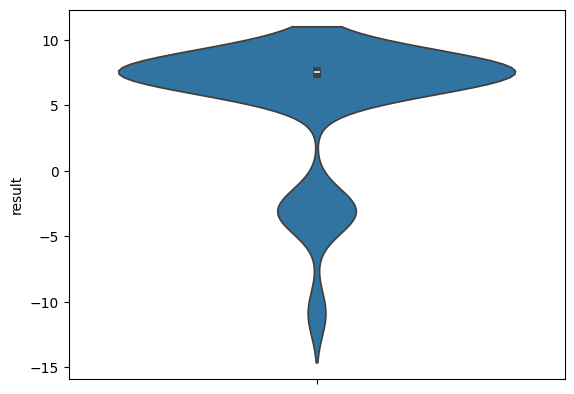

In [19]:
import seaborn as sns

sns.violinplot(data=df,y='result')

<Axes: ylabel='user_prompt'>

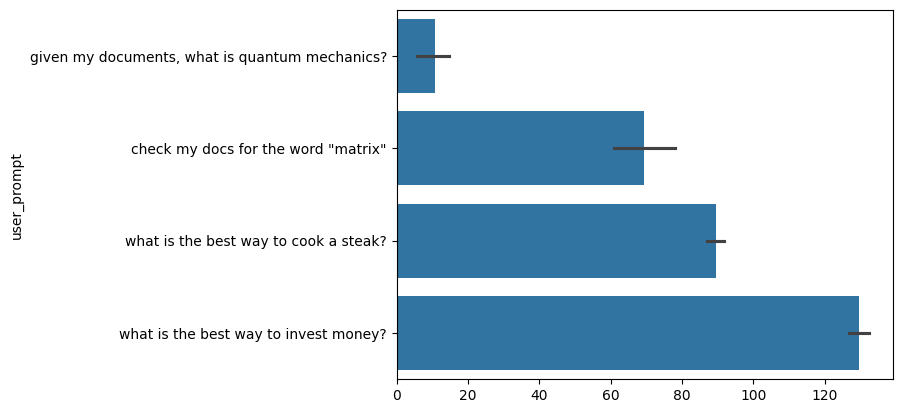

In [20]:
sns.barplot(df.loc[df['result']<0]["user_prompt"])

<Axes: ylabel='correct_tool'>

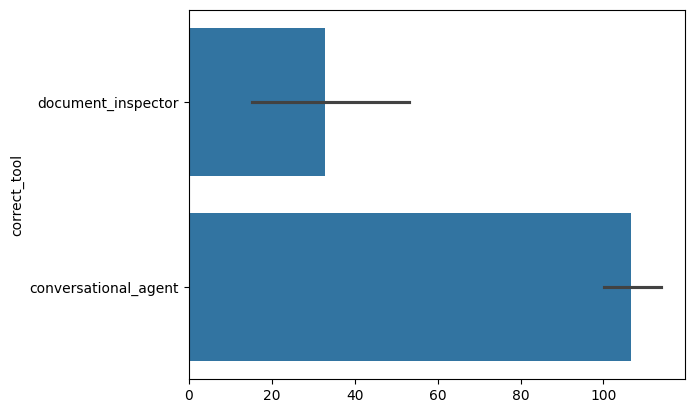

In [21]:
sns.barplot(df.loc[df['result']<0]["correct_tool"])

<Axes: ylabel='selected_tool'>

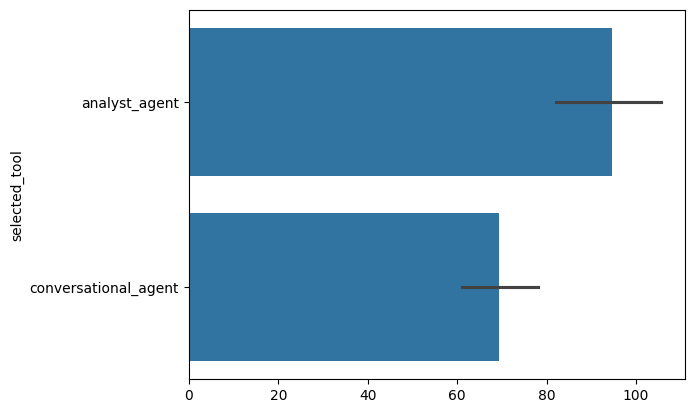

In [22]:
sns.barplot(df.loc[df['result']<0]["selected_tool"])